#### predictive modeling of soil oragnic carbon with samples from Italy ####

In [1]:
# loading necessary packages

library(prospectr)
library(resemble)
library(caret)
library(pls)
library(randomForest)
library(ranger)

prospectr version 0.2.8 -- galo

check the package repository at: https://github.com/l-ramirez-lopez/prospectr

resemble version 2.2.5 -- dstatements

check the package repository at: http://l-ramirez-lopez.github.io/resemble/

Loading required package: ggplot2

Loading required package: lattice


Attaching package: ‘pls’


The following object is masked from ‘package:caret’:

    R2


The following object is masked from ‘package:prospectr’:

    msc


The following object is masked from ‘package:stats’:

    loadings


randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:ggplot2’:

    margin



Attaching package: ‘ranger’


The following object is masked from ‘package:randomForest’:

    importance




In [2]:
# read the data and get the variables

setwd("/home/camahubuntu/Spectroscopy/italy_soc")

lab <- read.csv("Italy_lab.csv")

VNIR<-read.csv("Italy_spc.csv")
VNIR<-VNIR[,-1]

wl <- read.csv("Italy_spc.csv", header = FALSE)
wl <- as.numeric(wl[1, ])
wl <- wl[!is.na(wl)]

In [3]:
VNIR

X500,X502,X504,X506,X508,X510,X512,X514,X516,X518,⋯,X2480,X2482,X2484,X2486,X2488,X2490,X2492,X2494,X2496,X2498
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.13401595,0.13518842,0.13639392,0.13763535,0.13890856,0.14021436,0.14153977,0.14288890,0.14426501,0.14566728,⋯,0.4097656,0.4087210,0.4076482,0.4065524,0.4054114,0.4042383,0.4030742,0.4019541,0.4009276,0.4000060
0.19403385,0.19547085,0.19693754,0.19844767,0.19997951,0.20154754,0.20313652,0.20475735,0.20640632,0.20807433,⋯,0.4826669,0.4812292,0.4796368,0.4778736,0.4759716,0.4739854,0.4719810,0.4700310,0.4682001,0.4665256
0.35591066,0.35927583,0.36272751,0.36626802,0.36984777,0.37345820,0.37710084,0.38076542,0.38444879,0.38814009,⋯,0.5645716,0.5633580,0.5621659,0.5609879,0.5598188,0.5586728,0.5575875,0.5565478,0.5555863,0.5547752
0.27002781,0.27266067,0.27535661,0.27812114,0.28091763,0.28374486,0.28660087,0.28947696,0.29237955,0.29530582,⋯,0.5136154,0.5123102,0.5110278,0.5097298,0.5083941,0.5070438,0.5057431,0.5045207,0.5033841,0.5023605
0.17510014,0.17631428,0.17755770,0.17884014,0.18013993,0.18146087,0.18279655,0.18415542,0.18553058,0.18691816,⋯,0.4498855,0.4489009,0.4478303,0.4467067,0.4455577,0.4444225,0.4433396,0.4423372,0.4414469,0.4406797
0.21898860,0.22072829,0.22250512,0.22432827,0.22617729,0.22806414,0.22996778,0.23188759,0.23382045,0.23576265,⋯,0.5169279,0.5162178,0.5155034,0.5147508,0.5139762,0.5132400,0.5125450,0.5118686,0.5112437,0.5107266
0.27373826,0.27580745,0.27792909,0.28011089,0.28231536,0.28455125,0.28680816,0.28908097,0.29137414,0.29368719,⋯,0.5443096,0.5436514,0.5429458,0.5421931,0.5414352,0.5406678,0.5399344,0.5392945,0.5387403,0.5382320
0.09974072,0.10072876,0.10175693,0.10282175,0.10391829,0.10504454,0.10619572,0.10737421,0.10858167,0.10981812,⋯,0.3621554,0.3615301,0.3609313,0.3604010,0.3599204,0.3594699,0.3590558,0.3586877,0.3583856,0.3581360
0.09513822,0.09612016,0.09713763,0.09819254,0.09927914,0.10039290,0.10153307,0.10270285,0.10390382,0.10513638,⋯,0.3533190,0.3526590,0.3519666,0.3512877,0.3506497,0.3500499,0.3495003,0.3489932,0.3485247,0.3481509


In [ ]:
# try different preprocessing steps for the later model 


nXr00<-as.matrix(VNIR) # reflectance without further preprocessing
nXr01<-sweep(nXr00, MARGIN=1, apply(nXr00, 1, function(x) (mean(x))), FUN="/")# mean centering # wirklich richtige Formel?
nXr02<-standardNormalVariate(nXr00) # SNV
nXr03<-detrend(nXr00, wl) # Detrend, requires additional information on wavelengths/wavenumbers
nXr04<-savitzkyGolay(nXr00, m=1, p=2, w=5) # 1st derivative (Savitzky-Golay)

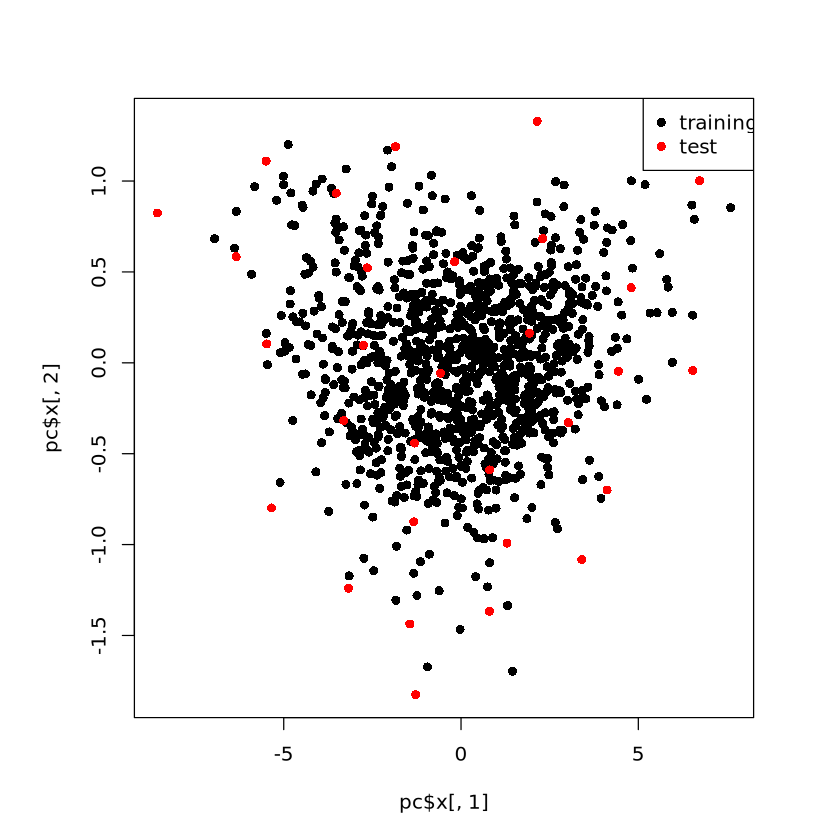

In [9]:
# model with Golay Preprocessing
nXdat<-nXr00

# first we choose 30% of the data as validation
nt<-30

# then we use a PC Kennard-Stone algorithm
split<-kenStone(X = nXdat, 
                k = nt, 
                metric="mahal",
                pc=0.95,   # based on PC feature space explaining 95% of overall variance of the spectra
                .center = TRUE,
                .scale = FALSE)


# which samples are defined as test set
test<-split$model

# which samples are defined as calibration set
train<-split$test

# Plot in PC feature space
pc<-prcomp(nXdat, center=T, scale. = F, rank. = 5)

par(pty="s")      # pty="s" ---> squared plot, regardless of the plot window size
matplot(pc$x[,1],   # scores of first PC
        pc$x[,2],   # scores of second PC
        pch=16)     # filled points

# adding test set
matpoints(pc$x[test,1], # only test set samples, 1st PC
          pc$x[test,2], # only test set samples, 2nd PC
          pch=16, 
          col="red")

legend("topright", c("training", "test"), pch=16, col=c("black", "red"))

Data: 	X dimension: 1150 1000 
	Y dimension: 1150 1
Fit method: oscorespls
Number of components considered: 20
TRAINING: % variance explained
        1 comps  2 comps  3 comps  4 comps  5 comps  6 comps  7 comps  8 comps
X        93.469    97.10    97.99    99.36    99.77    99.87    99.92    99.94
Ytrain    9.247    19.79    29.18    34.13    44.72    50.68    55.24    60.49
        9 comps  10 comps  11 comps  12 comps  13 comps  14 comps  15 comps
X         99.96     99.97     99.97     99.98     99.98     99.99     99.99
Ytrain    63.05     66.58     68.84     69.70     70.05     70.49     71.09
        16 comps  17 comps  18 comps  19 comps  20 comps
X          99.99     99.99     99.99     99.99    100.00
Ytrain     72.38     72.82     73.30     73.58     73.85
Data: 	X dimension: 1150 1000 
	Y dimension: 1150 1
Fit method: oscorespls
Number of components considered: 20

VALIDATION: RMSEP
Cross-validated using 10 random segments.
       (Intercept)  1 comps  2 comps  3 comps  4 c

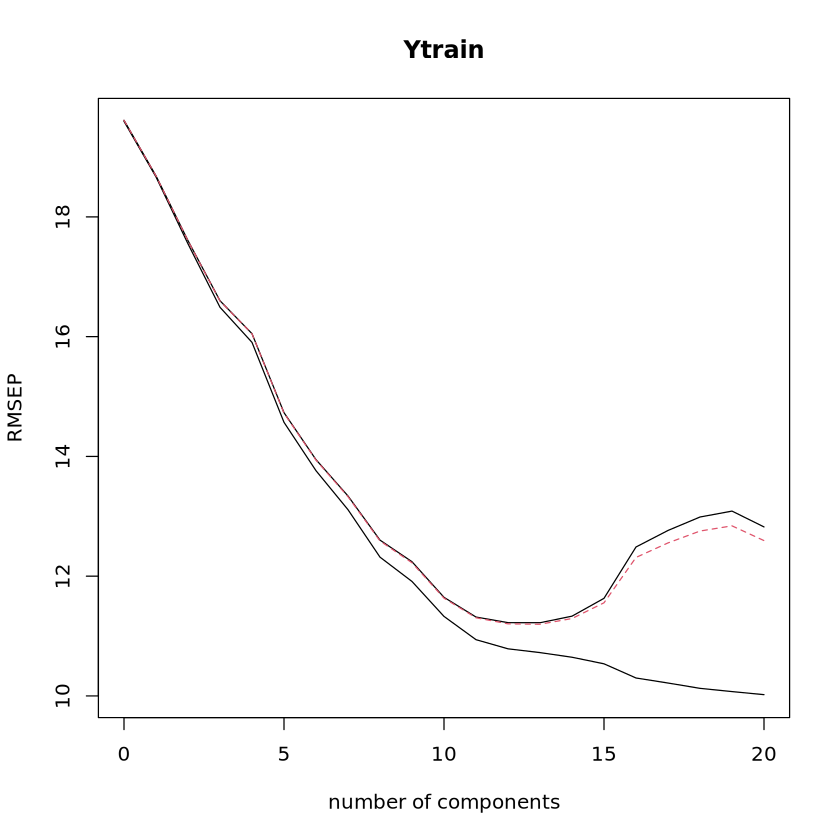

In [11]:
# now we calculate the PLS model with the preprocessed data

nXdat<-nXr00 

Ytrain <- as.matrix(lab$SOC[train])   # calibration set
Xtrain <- as.matrix(nXdat[train,])     # calibration set

# Model without cross validation
modf <- plsr(Ytrain~Xtrain,       # variables
             ncomp=20,  # max. number of latent variables to compute
             method="oscorespls",    # oscorespls = NIPALS = standard PLS
             validation="none")      # without any validation
summary(modf)

# Model with 10-fold cross validation
set.seed(125)
modcv <- plsr(Ytrain~Xtrain,        # variables
              ncomp=20,   # max. number of latent variables to compute
              method="oscorespls",     # oscorespls = NIPALS 
              validation="CV",   # with n-fold cross-validation
              segments=10)       # n of segments = 10 --> 10-fold CV
summary(modcv)

# RMSE of model fit
err_fit<-RMSEP(modf)

# RMSE of cross validation
err_modcv<-RMSEP(modcv)

# plot them together
plot(err_fit)       # RMSEcv of model fit
plot(err_modcv, add=T)# RMSEcv of cross validation - find optimal number of latent variables
# with increasing number of latent variables, PLS is able to explain an increasing amount of 
# variance of Y

# with cross validation, we can define the point where the model is overfitting, i.e. where the model
# uses sample specific noise to explain Y, which results in an increase of RMSE in the test set
